# Project Part 3 — Channel Coding
## Text Source: Token-Level



In [1]:
import math, random, collections, heapq
import matplotlib.pyplot as plt
from transformers import GPT2TokenizerFast

tokenizer = GPT2TokenizerFast.from_pretrained('gpt2')
with open('Text.txt','r',encoding='utf-8') as f:
    raw = f.read()
tokens = tokenizer.encode(raw)
n = len(tokens)
avg_cpt = len(raw)/n
probs = {x:c/n for x,c in collections.Counter(tokens).items()}

def entropy(p): return -sum(v*math.log2(v) for v in p.values() if v>0)

def build_huffman(prob_dict):
    heap=[[p,i,sym,None,None] for i,(sym,p) in enumerate(prob_dict.items())]
    heapq.heapify(heap);nid=len(prob_dict)
    while len(heap)>1:
        l=heapq.heappop(heap);r=heapq.heappop(heap)
        heapq.heappush(heap,[l[0]+r[0],nid,None,l,r]);nid+=1
    return heap[0]

def get_codes(tree,prefix='',codes={}):
    if tree[2] is not None:codes[tree[2]]=prefix or '0'
    else:get_codes(tree[3],prefix+'0',codes);get_codes(tree[4],prefix+'1',codes)
    return codes

tree  = build_huffman(probs)
codes = get_codes(tree,'',{})
rev   = {v:k for k,v in codes.items()}

sample_tokens = tokens[:2000]
compressed_bits = [int(b) for s in sample_tokens for b in codes[s]]

H = entropy(probs)
print(f'Tokens compressed : {len(sample_tokens)}')
print(f'Compressed bits   : {len(compressed_bits)}')
print(f'Bits/token        : {len(compressed_bits)/len(sample_tokens):.4f}')
print(f'H(X) bits/token   : {H:.4f}')

PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.
Token indices sequence length is longer than the specified maximum sequence length for this model (42596 > 1024). Running this sequence through the model will result in indexing errors


Tokens compressed : 2000
Compressed bits   : 15861
Bits/token        : 7.9305
H(X) bits/token   : 7.8656


---
## Task 1 — Binary Symmetric Channel
### Q1a-b: BSC and sensitivity analysis

In [2]:
def bsc(bits,p,seed=42):
    rng=random.Random(seed)
    return [b^(1 if rng.random()<p else 0) for b in bits]

def bits_to_tokens(bits, rev_codes):
    decoded, buf = [], ''
    for bit in bits:
        buf+=str(bit)
        if buf in rev_codes: decoded.append(rev_codes[buf]);buf=''
        if len(buf)>50: buf=''
    return decoded

print('BSC effect on compressed tokens:')
for p in [1e-3, 1e-2, 5e-2]:
    noisy = bsc(compressed_bits,p)
    ber   = sum(a!=b for a,b in zip(compressed_bits,noisy))/len(compressed_bits)
    dec   = bits_to_tokens(noisy,rev)
    ml    = min(len(dec),len(sample_tokens))
    ser   = sum(a!=b for a,b in zip(dec[:ml],sample_tokens[:ml]))/max(ml,1)
    print(f'  p={p:.0e}: BER={ber:.4f}, TER (token error rate)={ser:.4f}')

BSC effect on compressed tokens:
  p=1e-03: BER=0.0015, TER (token error rate)=0.9670
  p=1e-02: BER=0.0100, TER (token error rate)=0.9180
  p=5e-02: BER=0.0462, TER (token error rate)=0.9675


---
## Task 2 — Repetition Coding
### Q2a-b: Majority vote decoding

In [3]:
def repeat_encode(bits,r): return [b for b in bits for _ in range(r)]
def repeat_decode(bits,r):
    return [1 if sum(bits[i:i+r])>r//2 else 0 for i in range(0,len(bits)-r+1,r)]

p = 0.01
print(f'Repetition coding (tokens, p={p}):')
for r in [3,5,7]:
    enc=repeat_encode(compressed_bits,r);noisy=bsc(enc,p);db=repeat_decode(noisy,r)
    ml=min(len(db),len(compressed_bits))
    ber=sum(a!=b for a,b in zip(db[:ml],compressed_bits[:ml]))/max(ml,1)
    dec=bits_to_tokens(db,rev);ml2=min(len(dec),len(sample_tokens))
    ter=sum(a!=b for a,b in zip(dec[:ml2],sample_tokens[:ml2]))/max(ml2,1)
    print(f'  r={r}: BER={ber:.6f}, TER={ter:.4f}, rate={1/r:.3f}')

Repetition coding (tokens, p=0.01):
  r=3: BER=0.000252, TER=0.4190, rate=0.333
  r=5: BER=0.000000, TER=0.0000, rate=0.200
  r=7: BER=0.000000, TER=0.0000, rate=0.143


---
## Task 3 — Hamming(7,4) Coding

In [4]:
def hamming_encode_nibble(d):
    d1,d2,d3,d4=d
    return [d1^d2^d4,d1^d3^d4,d1,d2^d3^d4,d2,d3,d4]

def hamming_decode_nibble(c):
    p1,p2,d1,p3,d2,d3,d4=c
    s1=p1^d1^d2^d4;s2=p2^d1^d3^d4;s3=p3^d2^d3^d4
    syn=s1+2*s2+4*s3;bits=list(c)
    if syn!=0:bits[syn-1]^=1
    return [bits[2],bits[4],bits[5],bits[6]]

def hamming_encode(bits):
    padded=bits+[0]*((4-len(bits)%4)%4);enc=[]
    for i in range(0,len(padded),4):enc.extend(hamming_encode_nibble(padded[i:i+4]))
    return enc

def hamming_decode(bits):
    dec=[]
    for i in range(0,len(bits)-6,7):dec.extend(hamming_decode_nibble(bits[i:i+7]))
    return dec

p=0.01
enc=hamming_encode(compressed_bits);noisy=bsc(enc,p);db=hamming_decode(noisy)
ml=min(len(db),len(compressed_bits))
ber=sum(a!=b for a,b in zip(db[:ml],compressed_bits[:ml]))/max(ml,1)
dec=bits_to_tokens(db,rev);ml2=min(len(dec),len(sample_tokens))
ter=sum(a!=b for a,b in zip(dec[:ml2],sample_tokens[:ml2]))/max(ml2,1)
print(f'Hamming(7,4) at p={p}: BER={ber:.6f}, TER={ter:.4f}, rate={4/7:.3f}')

Hamming(7,4) at p=0.01: BER=0.000757, TER=0.3440, rate=0.571


---
## Task 4 — Full Comparison + Plot

In [5]:
p=0.01
print(f'=== Channel Coding Comparison (tokens, p={p}) ===')
print(f'{"Scheme":<25} {"Rate":>8} {"BER out":>12} {"TER":>10}')
print('-'*60)

noisy=bsc(compressed_bits,p)
ber=sum(a!=b for a,b in zip(compressed_bits,noisy))/len(compressed_bits)
dec=bits_to_tokens(noisy,rev);ml=min(len(dec),len(sample_tokens))
ter=sum(a!=b for a,b in zip(dec[:ml],sample_tokens[:ml]))/max(ml,1)
print(f'{"No coding":<25} {"1.000":>8} {ber:>12.6f} {ter:>10.4f}')

for r in [3,5,7]:
    enc=repeat_encode(compressed_bits,r);noisy=bsc(enc,p);db=repeat_decode(noisy,r)
    ml=min(len(db),len(compressed_bits))
    ber=sum(a!=b for a,b in zip(db[:ml],compressed_bits[:ml]))/max(ml,1)
    dec=bits_to_tokens(db,rev);ml2=min(len(dec),len(sample_tokens))
    ter=sum(a!=b for a,b in zip(dec[:ml2],sample_tokens[:ml2]))/max(ml2,1)
    print(f'{f"Repetition r={r}":<25} {1/r:>8.3f} {ber:>12.6f} {ter:>10.4f}')

enc=hamming_encode(compressed_bits);noisy=bsc(enc,p);db=hamming_decode(noisy)
ml=min(len(db),len(compressed_bits))
ber=sum(a!=b for a,b in zip(db[:ml],compressed_bits[:ml]))/max(ml,1)
dec=bits_to_tokens(db,rev);ml2=min(len(dec),len(sample_tokens))
ter=sum(a!=b for a,b in zip(dec[:ml2],sample_tokens[:ml2]))/max(ml2,1)
print(f'{"Hamming(7,4)":<25} {4/7:>8.3f} {ber:>12.6f} {ter:>10.4f}')

=== Channel Coding Comparison (tokens, p=0.01) ===
Scheme                        Rate      BER out        TER
------------------------------------------------------------
No coding                    1.000     0.010025     0.9180
Repetition r=3               0.333     0.000252     0.4190
Repetition r=5               0.200     0.000000     0.0000
Repetition r=7               0.143     0.000000     0.0000
Hamming(7,4)                 0.571     0.000757     0.3440


### BER vs p — all schemes (tokens)

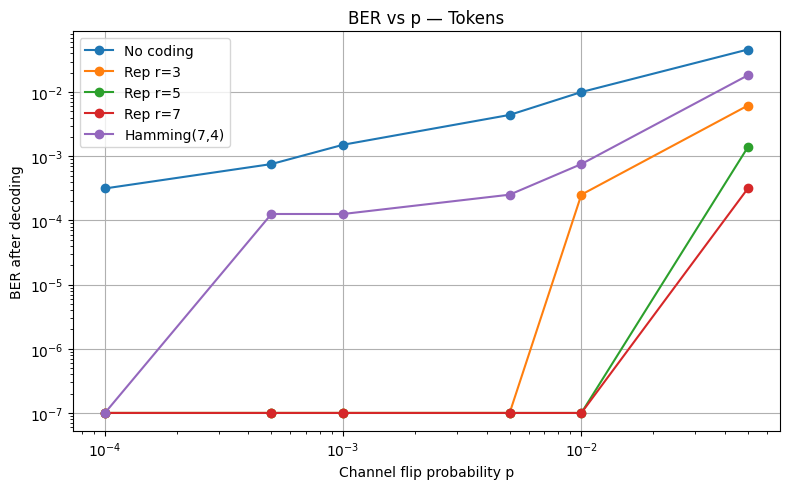

In [6]:
p_vals=[1e-4,5e-4,1e-3,5e-3,1e-2,5e-2]
bers_no,bers_r3,bers_r5,bers_r7,bers_ham=[],[],[],[],[]

for p in p_vals:
    noisy=bsc(compressed_bits,p)
    bers_no.append(sum(a!=b for a,b in zip(compressed_bits,noisy))/len(compressed_bits))
    for r,lst in [(3,bers_r3),(5,bers_r5),(7,bers_r7)]:
        enc=repeat_encode(compressed_bits,r);noisy=bsc(enc,p);db=repeat_decode(noisy,r)
        ml=min(len(db),len(compressed_bits))
        lst.append(sum(a!=b for a,b in zip(db[:ml],compressed_bits[:ml]))/max(ml,1))
    enc=hamming_encode(compressed_bits);noisy=bsc(enc,p);db=hamming_decode(noisy)
    ml=min(len(db),len(compressed_bits))
    bers_ham.append(sum(a!=b for a,b in zip(db[:ml],compressed_bits[:ml]))/max(ml,1))

plt.figure(figsize=(8,5))
for label,data in [('No coding',bers_no),('Rep r=3',bers_r3),
                    ('Rep r=5',bers_r5),('Rep r=7',bers_r7),('Hamming(7,4)',bers_ham)]:
    plt.loglog(p_vals,[max(d,1e-7) for d in data],marker='o',label=label)
plt.xlabel('Channel flip probability p'); plt.ylabel('BER after decoding')
plt.title('BER vs p — Tokens'); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.savefig('token_ber_vs_p.png',dpi=100); plt.show()